In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

Mounted at /content/drive


In [ ]:
!pip install -q transformers>=4.37 accelerate timm
!pip install -q torch torchvision
!pip install -q opencv-python-headless albumentations
!pip install -q matplotlib tqdm scikit-learn
print("Done.")

Done.


In [ ]:
import cv2, numpy as np
from pathlib import Path
from tqdm import tqdm
from PIL import Image
import json
import os
import shutil

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn, torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

import albumentations as A
from albumentations.pytorch import ToTensorV2

from transformers import SegformerForSemanticSegmentation
from transformers import SegformerForSemanticSegmentation as SF

In [ ]:
DRIVE_ROOT    = '/content/drive/MyDrive/CVRoadMarkDetection/dataset'
TRAIN_IMG_DIR = os.path.join(DRIVE_ROOT, 'train/images')
TRAIN_LBL_DIR = os.path.join(DRIVE_ROOT, 'train/labels')
VALID_IMG_DIR = os.path.join(DRIVE_ROOT, 'valid/images')
VALID_LBL_DIR = os.path.join(DRIVE_ROOT, 'valid/labels')
TEST_IMG_DIR  = os.path.join(DRIVE_ROOT, 'test/images')
TEST_LBL_DIR  = os.path.join(DRIVE_ROOT, 'test/labels')

In [ ]:
MASK_DIR = '/content/drive/MyDrive/CVRoadMarkDetection/SegFormer/masks'
CKPT_DIR = '/content/drive/MyDrive/CVRoadMarkDetection/SegFormer/Training2/checkpoints'
for d in [MASK_DIR+'/train', MASK_DIR+'/valid', MASK_DIR+'/test', CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

CLASS_NAMES = [
    'BUS LANE', 'Yellow Markings', 'Line 1', 'Line 2',
    'Crossing', 'Romb', 'SLOW', 'Left Arrow',
    'Forward Arrow', 'Forward Arrow -Left', 'Forward Arrow -Right',
    'Right Arrow', 'Bicycle'
]
NUM_CLASSES = len(CLASS_NAMES)
print(f'NUM_CLASSES={NUM_CLASSES}')

NUM_CLASSES=13


In [ ]:
def yolo_seg_to_mask(label_path, img_path, out_dir):
    if img_path and Path(img_path).exists():
        H, W = cv2.imread(str(img_path)).shape[:2]
    else:
        H, W = 640, 640  # fallback

    mask = np.zeros((H, W), dtype=np.uint8)
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cid    = int(parts[0])
            coords = list(map(float, parts[1:]))
            pts    = np.array(
                [[int(coords[i]*W), int(coords[i+1]*H)]
                 for i in range(0, len(coords)-1, 2)],
                dtype=np.int32
            )
            if len(pts) >= 3:
                cv2.fillPoly(mask, [pts], color=int(cid + 1))  # 0=background

    out = Path(out_dir) / (Path(label_path).stem + '.png')
    cv2.imwrite(str(out), mask)

def convert_split(lbl_dir, img_dir, out_dir, name):
    files = list(Path(lbl_dir).glob('*.txt'))
    print(f'[{name}] {len(files)} label files...')
    for lbl in tqdm(files):
        img = next(
            (Path(img_dir)/(lbl.stem+ext)
             for ext in ['.jpg','.jpeg','.png','.JPG']
             if (Path(img_dir)/(lbl.stem+ext)).exists()),
            None
        )
        yolo_seg_to_mask(lbl, img, out_dir)
    print(f'  Done → {out_dir}')

# convert_split(TRAIN_LBL_DIR, TRAIN_IMG_DIR, MASK_DIR+'/train', 'train')
# convert_split(VALID_LBL_DIR, VALID_IMG_DIR, MASK_DIR+'/valid', 'valid')
# convert_split(TEST_LBL_DIR,  TEST_IMG_DIR,  MASK_DIR+'/test',  'test')

In [ ]:
IMG_SIZE   = 512
BATCH_SIZE = 4

train_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),        # valid for top-down UAV
    A.RandomRotate90(p=0.5),      # road marks can appear in any orientation
    A.RandomBrightnessContrast(0.3, 0.3, p=0.4),
    A.GaussNoise(var_limit=(10,50), p=0.2),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])
val_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

class RoadMarkDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.transform = transform
        self.samples   = []
        for ext in ['*.jpg','*.jpeg','*.png','*.JPG']:
            for ip in sorted(Path(img_dir).glob(ext)):
                mp = Path(mask_dir) / (ip.stem + '.png')
                if mp.exists():
                    self.samples.append((ip, mp))
        print(f'  {len(self.samples)} samples  [{img_dir}]')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        ip, mp = self.samples[idx]
        image  = np.array(Image.open(ip).convert('RGB'))
        mask   = np.array(Image.open(mp))  # uint8, 0=bg, 1-13=classes
        if self.transform:
            a = self.transform(image=image, mask=mask)
            image, mask = a['image'], a['mask']
        return image.float(), mask.long()

train_ds = RoadMarkDataset(TRAIN_IMG_DIR, MASK_DIR+'/train', train_tf)
val_ds   = RoadMarkDataset(VALID_IMG_DIR, MASK_DIR+'/valid', val_tf)
test_ds  = RoadMarkDataset(TEST_IMG_DIR,  MASK_DIR+'/test',  val_tf)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  1,          shuffle=False, num_workers=2)
print("DataLoaders ready.")

/tmp/ipykernel_9752/210120533.py:10: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10,50), p=0.2),


  2167 samples  [/content/drive/MyDrive/CVRoadMarkDetection/dataset/train/images]
  417 samples  [/content/drive/MyDrive/CVRoadMarkDetection/dataset/valid/images]
  192 samples  [/content/drive/MyDrive/CVRoadMarkDetection/dataset/test/images]
DataLoaders ready.


In [ ]:
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
id2label = {0: 'background', **{i+1: CLASS_NAMES[i] for i in range(NUM_CLASSES)}}
label2id = {v: k for k, v in id2label.items()}

model = SegformerForSemanticSegmentation.from_pretrained(
    'nvidia/mit-b2',
    num_labels             = NUM_CLASSES + 1,   # 14
    id2label               = id2label,
    label2id               = label2id,
    ignore_mismatched_sizes= True
).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
print(f'Total params: {total/1e6:.1f}M on {DEVICE}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/99.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/98.9M [00:00<?, ?B/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

Total params: 27.4M on cuda


In [ ]:
def compute_class_weights(loader, n_cls, max_batches=60):
    freq = torch.zeros(n_cls)
    for i, (_, m) in enumerate(loader):
        if i >= max_batches: break
        for c in range(n_cls):
            freq[c] += (m == c).sum()
    freq = freq / freq.sum()
    w = 1.0 / (freq + 1e-6)
    return w / w.sum() * n_cls

print("Computing class weights...")
cw = compute_class_weights(train_loader, NUM_CLASSES+1).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=cw, ignore_index=255)

# Differential LR: lower for frozen backbone features, higher for head
backbone_p = [p for n,p in model.named_parameters() if 'segformer' in n]
head_p     = [p for n,p in model.named_parameters() if 'decode_head' in n]

NUM_EPOCHS = 23
optimizer  = AdamW([{'params': backbone_p, 'lr': 6e-5},
                    {'params': head_p,     'lr': 6e-4}], weight_decay=0.01)
scheduler  = OneCycleLR(optimizer, max_lr=[6e-5, 6e-4],
                        steps_per_epoch=len(train_loader),
                        epochs=NUM_EPOCHS, pct_start=0.1)
print(f"Ready: {NUM_EPOCHS} epochs")

Computing class weights...
Ready: 23 epochs


In [ ]:
def compute_miou(preds, targets, n_cls):
    ious = []
    for c in range(1, n_cls):  # skip background
        p = (preds==c); t = (targets==c)
        inter = (p & t).sum().item()
        union = (p | t).sum().item()
        if union > 0: ious.append(inter/union)
    return sum(ious)/len(ious) if ious else 0.0

def evaluate(model, loader, n_cls, device):
    model.eval()
    tot_loss = tot_miou = n = 0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = F.interpolate(model(pixel_values=imgs).logits,
                                   size=masks.shape[-2:], mode='bilinear', align_corners=False)
            tot_loss += criterion(logits, masks).item()
            tot_miou += compute_miou(logits.argmax(1).cpu(), masks.cpu(), n_cls)
            n += 1
    return tot_loss/n, tot_miou/n

In [ ]:
history   = {k:[] for k in ['train_loss','val_loss','train_miou','val_miou']}
best_miou = 0.0
BEST_CKPT = os.path.join(CKPT_DIR, 'segformer_best.pth')

if os.path.exists(BEST_CKPT):
    print("Loading Checkpoint...")
    checkpoint = torch.load(BEST_CKPT)

    model.load_state_dict(checkpoint['state'])

    start_epoch = checkpoint['epoch']
    best_miou = checkpoint['miou']

    print(f"Resuming from Epoch {start_epoch} with mIoU: {best_miou:.4f}")
else:
    print("No checkpoint found. Starting from scratch.")
    start_epoch = 0
    best_miou = 0.0

patience = 5
counter = 0
early_stop = False

for epoch in range(start_epoch + 1, start_epoch + NUM_EPOCHS + 1):
    model.train()
    ep_loss = ep_miou = n = 0
    pbar = tqdm(train_loader, desc=f'Ep {epoch:02d}/{NUM_EPOCHS}', leave=False)

    for imgs, masks in pbar:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        logits = F.interpolate(model(pixel_values=imgs).logits,
                               size=masks.shape[-2:], mode='bilinear', align_corners=False)
        loss = criterion(logits, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        ep_loss += loss.item()
        ep_miou += compute_miou(logits.detach().argmax(1).cpu(), masks.cpu(), NUM_CLASSES+1)
        n += 1
        pbar.set_postfix(loss=f'{ep_loss/n:.4f}', miou=f'{ep_miou/n:.4f}')

    tl, tm = ep_loss/n, ep_miou/n
    vl, vm = evaluate(model, val_loader, NUM_CLASSES+1, DEVICE)

    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['train_miou'].append(tm)
    history['val_miou'].append(vm)

    history_path = os.path.join(CKPT_DIR, 'training_history.json')
    with open(history_path, 'w') as f:
        json.dump(history, f)

    print(f'Ep {epoch:02d} | Train L:{tl:.4f} mIoU:{tm:.4f} | Val L:{vl:.4f} mIoU:{vm:.4f}')

    if vm > best_miou:
        best_miou = vm
        counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'miou': vm,
            'history': history
        }, BEST_CKPT)
        print(f'  ✓ Best saved (val mIoU={best_miou:.4f})')
    else:
        counter += 1
        print(f'  × No improvement for {counter} epoch(s).')
        if counter >= patience:
            print(f'!!! Early stopping triggered at epoch {epoch} !!!')
            early_stop = True

    if early_stop:
        break

print(f'Training done. Best val mIoU = {best_miou:.4f}')

Loading Checkpoint...


KeyError: 'state'

Successfully loaded history with 28 epochs.


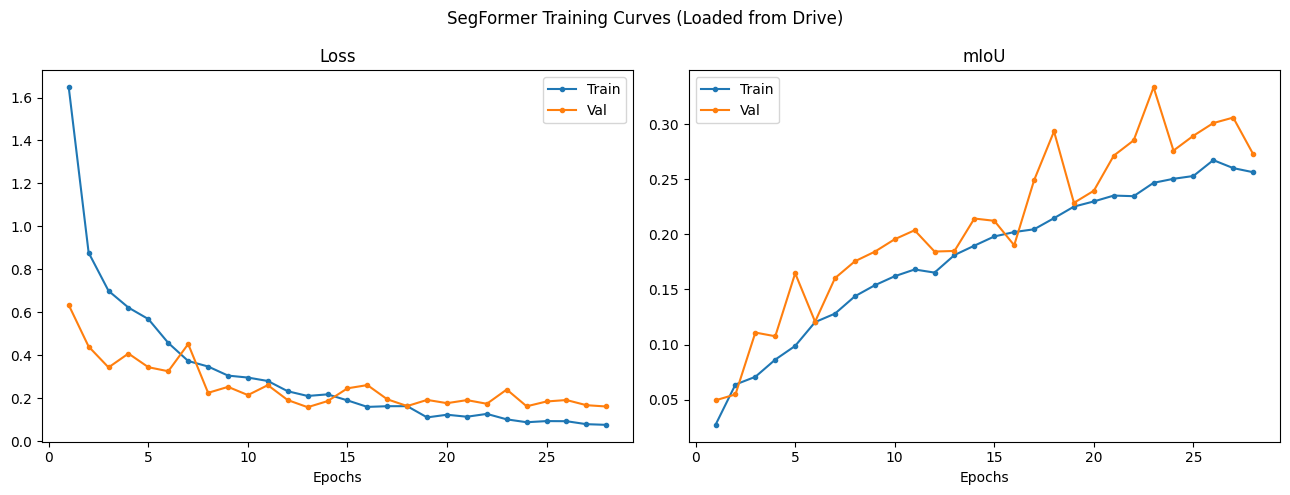

Plot updated and saved to: /content/drive/MyDrive/CVRoadMarkDetection/SegFormer/Training2/training_curves.png


In [ ]:
history_path = os.path.join(CKPT_DIR, 'training_history.json')

if os.path.exists(history_path):
    # 1. Fetch the data from Google Drive
    with open(history_path, 'r') as f:
        history = json.load(f)

    print(f"Successfully loaded history with {len(history['train_loss'])} epochs.")

    # 2. Plotting Logic
    ep = range(1, len(history['train_loss']) + 1)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))

    # Loss Curve
    a1.plot(ep, history['train_loss'], label='Train', marker='o', markersize=3)
    a1.plot(ep, history['val_loss'], label='Val', marker='o', markersize=3)
    a1.set_title('Loss')
    a1.set_xlabel('Epochs')
    a1.legend()

    # mIoU Curve
    a2.plot(ep, history['train_miou'], label='Train', marker='o', markersize=3)
    a2.plot(ep, history['val_miou'], label='Val', marker='o', markersize=3)
    a2.set_title('mIoU')
    a2.set_xlabel('Epochs')
    a2.legend()

    plt.suptitle('SegFormer Training Curves (Loaded from Drive)')
    plt.tight_layout()

    # Save back to Drive
    plot_path = '/content/drive/MyDrive/CVRoadMarkDetection/SegFormer/Training2/training_curves.png'
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"Plot updated and saved to: {plot_path}")

else:
    print(f"Error: Could not find history file at {history_path}. Run the training loop first!")

In [ ]:
# Load the checkpoint
ckpt = torch.load(BEST_CKPT, map_location=DEVICE)

# Fix: Use 'model_state_dict' instead of 'state'
# based on your saving logic in Cell 10
model.load_state_dict(ckpt['model_state_dict'])

print(f'Loaded epoch {ckpt["epoch"]} (val mIoU={ckpt["miou"]:.4f})')

def per_class_iou(model, loader, n_cls, device):
    model.eval()
    inter = torch.zeros(n_cls)
    union = torch.zeros(n_cls)
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc='Testing'):
            # Standard SegFormer forward pass
            outputs = model(pixel_values=imgs.to(device))

            # Upscale logits to match the ground truth mask size
            logits = F.interpolate(
                outputs.logits,
                size=masks.shape[-2:],
                mode='bilinear',
                align_corners=False
            )

            preds = logits.argmax(1).cpu()
            for c in range(n_cls):
                p = (preds == c)
                t = (masks == c)
                inter[c] += (p & t).sum()
                union[c] += (p | t).sum()

    return inter / (union + 1e-6)

# Execute evaluation
iou = per_class_iou(model, test_loader, NUM_CLASSES + 1, DEVICE)
mean_iou = iou[1:].mean().item()  # Calculate mean across foreground classes

# Print results
print(f'\n{"Class":<28} {"IoU":>8}')
print('-' * 38)
for i, nm in enumerate(['background'] + CLASS_NAMES):
    print(f'{nm:<28} {iou[i].item():.4f}')

print(f'\nmIoU (foreground): {mean_iou:.4f}')

Loaded epoch 23 (val mIoU=0.3337)


Testing: 100%|██████████| 192/192 [03:03<00:00,  1.04it/s]


Class                             IoU
--------------------------------------
background                   0.9676
BUS LANE                     0.6120
Yellow Markings              0.7430
Line 1                       0.2758
Line 2                       0.1163
Crossing                     0.6294
Romb                         0.4513
SLOW                         0.4837
Left Arrow                   0.5634
Forward Arrow                0.4583
Forward Arrow -Left          0.4196
Forward Arrow -Right         0.2682
Right Arrow                  0.2923
Bicycle                      0.2464

mIoU (foreground): 0.4277


In [ ]:
baseline = SF.from_pretrained('nvidia/mit-b2', num_labels=NUM_CLASSES+1,
    id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True).to(DEVICE)

b_iou   = per_class_iou(baseline, test_loader, NUM_CLASSES+1, DEVICE)
b_miou  = b_iou[1:].mean().item()

print(f'\nBaseline mIoU  (no fine-tune) : {b_miou:.4f}')
print(f'Fine-tuned mIoU               : {mean_iou:.4f}')
print(f'Improvement                   : +{mean_iou-b_miou:.4f}')

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta


Baseline mIoU  (no fine-tune) : 0.0008
Fine-tuned mIoU               : 0.4277
Improvement                   : +0.4269


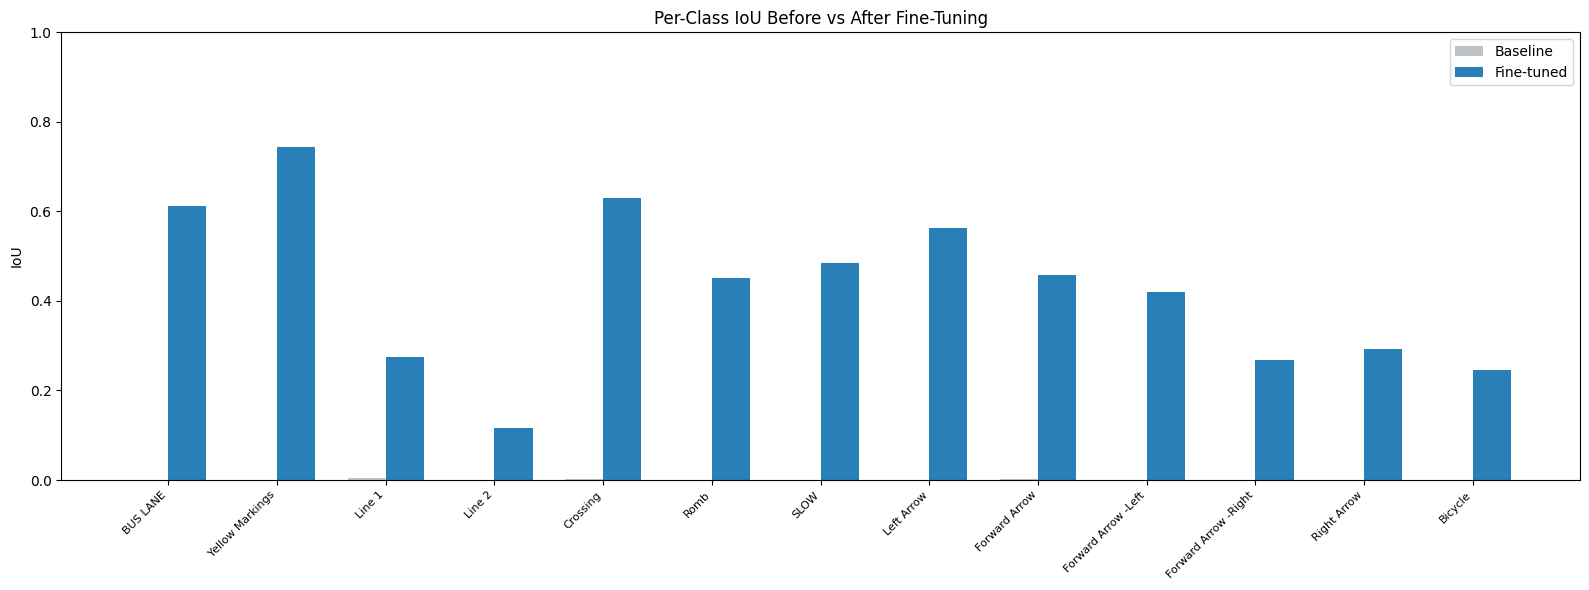

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6), facecolor='none')
ax.set_facecolor('none')
x = np.arange(NUM_CLASSES); w = 0.35
ax.bar(x-w/2, b_iou[1:].numpy(), w, label='Baseline', color='#bdc3c7')
ax.bar(x+w/2, iou[1:].numpy(),   w, label='Fine-tuned', color='#2980b9')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_ylim(0,1); ax.set_ylabel('IoU'); ax.legend()
ax.set_title('Per-Class IoU Before vs After Fine-Tuning')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CVRoadMarkDetection/SegFormer/Training2/transfer_learning_comparison.png', dpi=150); plt.show()

In [ ]:
OUT = '/content/drive/MyDrive/CVRoadMarkDetection/SegFormer/Training2/segformer_output'
os.makedirs(OUT, exist_ok=True)
model.save_pretrained(OUT+'/model')
for f in ['training_curves.png','transfer_learning_comparison.png']:
    shutil.copy(f'/content/drive/MyDrive/CVRoadMarkDetection/SegFormer/Training2/{f}', os.path.join(OUT, f))
print(f'Saved → {OUT}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved → /content/drive/MyDrive/CVRoadMarkDetection/SegFormer/Training2/segformer_output


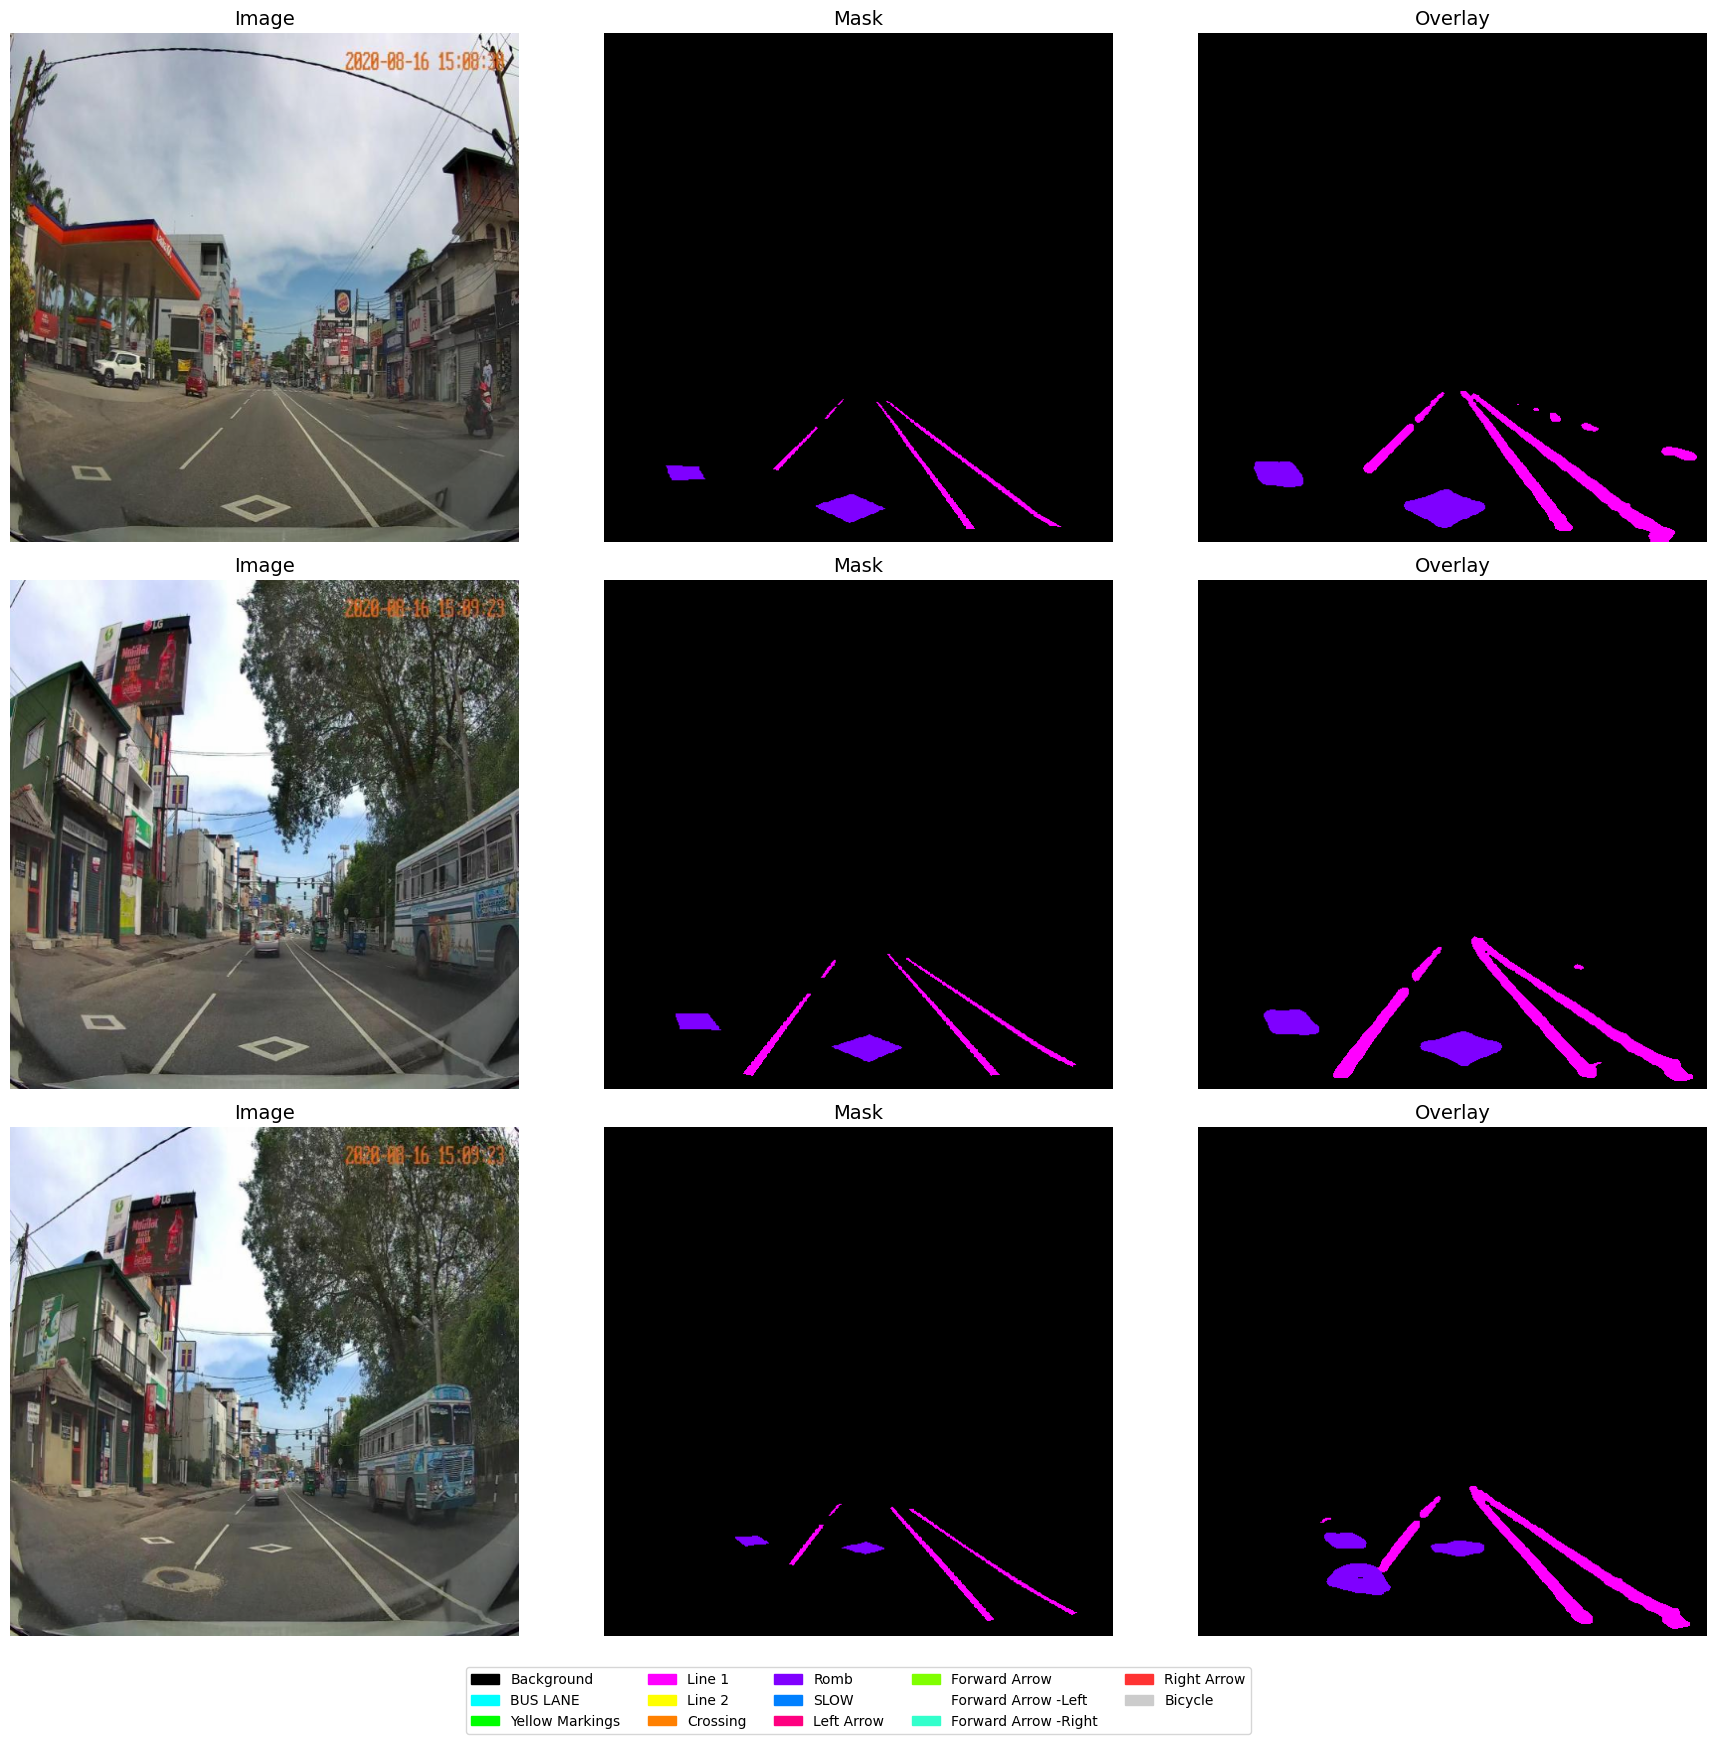

In [ ]:
def visualize_neon_grid(model, dataset, device, class_names):
    model.eval()
    n_samples = 3

    # 1. Define Neon Colors (RGB normalized 0-1)
    # Background is Black [0,0,0]
    # Markings use vibrant Cyan, Lime, Magenta, Yellow, Orange, etc.
    neon_colors = [
        [0, 0, 0],           # 0: Background (Black)
        [0, 1, 1],           # 1: Cyan
        [0, 1, 0],           # 2: Lime
        [1, 0, 1],           # 3: Magenta
        [1, 1, 0],           # 4: Yellow
        [1, 0.5, 0],         # 5: Orange
        [0.5, 0, 1],         # 6: Purple
        [0, 0.5, 1],         # 7: Sky Blue
        [1, 0, 0.5],         # 8: Hot Pink
        [0.5, 1, 0],         # 9: Chartreuse
        [1, 1, 1],           # 10: White
        [0.2, 1, 0.8],       # 11: Aquamarine
        [1, 0.2, 0.2],       # 12: Neon Red
        [0.8, 0.8, 0.8]      # 13: Silver/Grey
    ]

    # Ensure we have enough colors for all classes
    while len(neon_colors) < len(class_names) + 1:
        neon_colors.append(list(np.random.random(3)))

    custom_cmap = ListedColormap(neon_colors[:len(class_names)+1])

    fig, axes = plt.subplots(n_samples, 3, figsize=(18, 18), facecolor='white')

    indices = range(n_samples) # Or random.sample(range(len(dataset)), n_samples)

    for i, idx in enumerate(indices):
        image, mask = dataset[idx]

        # Inference
        input_tensor = image.unsqueeze(0).to(device)
        with torch.no_grad():
            outputs = model(pixel_values=input_tensor)
            logits = F.interpolate(outputs.logits, size=mask.shape[-2:],
                                   mode='bilinear', align_corners=False)
            prediction = logits.argmax(1).squeeze(0).cpu().numpy()

        # Reverse Normalization
        img_vis = image.permute(1, 2, 0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_vis = (img_vis * std + mean).clip(0, 1)

        # Create Overlay with Neon colors
        # We apply the custom_cmap to the prediction indices
        pred_colored = custom_cmap(prediction)

        # Alpha mask: Only show neon color where prediction > 0
        mask_alpha = np.where(prediction > 0, 0.6, 0.0)

        # --- Column 0: Image ---
        axes[i, 0].imshow(img_vis)
        axes[i, 0].set_title("Image", fontsize=14)
        axes[i, 0].axis("off")

        # --- Column 1: Mask (Black Background + Neon) ---
        axes[i, 1].imshow(mask.cpu().numpy(), cmap=custom_cmap, vmin=0, vmax=len(class_names))
        axes[i, 1].set_title("Mask", fontsize=14)
        axes[i, 1].axis("off")

        # --- Column 2: Overlay ---
        axes[i, 2].imshow(img_vis)
        axes[i, 2].imshow(pred_colored, alpha=mask_alpha)
        axes[i, 2].set_title("Overlay", fontsize=14)
        axes[i, 2].axis("off")

    # Legend Construction
    full_classes = ['Background'] + class_names
    legend_patches = [
        mpatches.Patch(color=neon_colors[j], label=full_classes[j])
        for j in range(len(full_classes))
    ]

    fig.legend(handles=legend_patches, loc='lower center', ncol=5,
               bbox_to_anchor=(0.5, 0.03), fontsize='medium', frameon=True)

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

# Execution
visualize_neon_grid(model, test_ds, DEVICE, CLASS_NAMES)

In [ ]:
@torch.no_grad()
def process_segformer_video_labeled(model_ckpt, input_path, output_path, device=DEVICE):
    # Ensure the directory exists
    output_dir = os.path.dirname(output_path)
    if not os.path.exists(output_dir):
        os.makedirs(output_dir, exist_ok=True)

    # 1. Load Model
    model.load_state_dict(torch.load(model_ckpt, map_location=device)['model_state_dict'])
    model.eval()

    # 2. Open Video
    cap = cv2.VideoCapture(input_path)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # 3. Setup Header (Extra space at the top for labels)
    header_h = 60  # Height of the black bar for text labels
    combined_width = width * 3
    combined_height = height + header_h

    # 4. Video Writer Setup
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (combined_width, combined_height))

    # 5. Color Palette
    neon_colors = np.array([
        [0, 0, 0], [0, 255, 255], [0, 255, 0], [255, 0, 255], [255, 255, 0],
        [255, 128, 0], [128, 0, 255], [0, 128, 255], [255, 0, 128], [128, 255, 0],
        [255, 255, 255], [50, 255, 200], [255, 50, 50], [200, 200, 200]
    ], dtype=np.uint8)

    print(f"Processing labeled comparison: {total_frames} frames...")

    for _ in tqdm(range(total_frames)):
        ret, frame = cap.read()
        if not ret: break

        # --- Inference Logic ---
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        augmented = val_tf(image=frame_rgb)
        input_tensor = augmented['image'].unsqueeze(0).to(device)
        outputs = model(pixel_values=input_tensor)

        logits = F.interpolate(outputs.logits, size=(height, width), mode='bilinear', align_corners=False)
        pred = logits.argmax(1).squeeze(0).cpu().numpy().astype(np.uint8)

        # --- View 1: Original ---
        view1 = frame.copy()

        # --- View 2: Original + Pred Seg Mask (Overlay) ---
        mask_rgb = neon_colors[pred]
        mask_bgr = cv2.cvtColor(mask_rgb, cv2.COLOR_RGB2BGR)
        alpha = 0.5
        binary_mask = (pred > 0).astype(np.float32)[:, :, np.newaxis]
        marking_areas = (mask_bgr * alpha + frame * (1 - alpha)).astype(np.uint8)
        view2 = np.where(binary_mask == 1, marking_areas, frame)

        # --- View 3: Pred Mask Only ---
        view3 = mask_bgr

        # --- Combine and Label ---
        # Create a blank canvas for the header + frames
        canvas = np.zeros((combined_height, combined_width, 3), dtype=np.uint8)

        # Place frames below the header area
        canvas[header_h:, 0:width] = view1
        canvas[header_h:, width:width*2] = view2
        canvas[header_h:, width*2:width*3] = view3

        # Add Labels
        labels = ["Original Video", "Original + Predicted Segmented Mask", "Predicted Mask"]
        for i, text in enumerate(labels):
            # Centering logic for text
            text_size = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1.2, 2)[0]
            text_x = (i * width) + (width - text_size[0]) // 2
            cv2.putText(canvas, text, (text_x, 40),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2, cv2.LINE_AA)

        out.write(canvas)

    cap.release()
    out.release()
    print(f"\nLabeled video saved to: {output_path}")


# --- EXECUTION ---
INPUT_VID = '/content/drive/MyDrive/CVRoadMarkDetection/videos/5.mp4'
OUTPUT_VID = '/content/drive/MyDrive/CVRoadMarkDetection/videos/SegFormer/5_Comparison_3Panel.mp4'

# process_segformer_video_labeled(BEST_CKPT, INPUT_VID, OUTPUT_VID)

Processing labeled comparison: 1231 frames...


100%|██████████| 1231/1231 [03:05<00:00,  6.64it/s]


Labeled video saved to: /content/drive/MyDrive/CVRoadMarkDetection/videos/SegFormer/5_Comparison_3Panel.mp4
